# Technology Focus: 10x Genomics Xenium (Simplified)

This tutorial highlights the basic functions of `SegTraQ` on a single Xenium dataset that was segmented using the Xenium default segmentation.
To follow along, you can download the data already in `SpatialData` format from [here](https://oc.embl.de/index.php/s/iGxVy8qtZnwHOju).

For a more detailed description of how the data was obtained and a comparison between segmentation methods, please look at the [Xenium Focus](10x_xenium_focus.ipynb).

## Read SpatialData object

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import warnings

import anndata as ad
import dask
import matplotlib.pyplot as plt
import pandas as pd
import scanpy as sc
import seaborn as sns
import spatialdata as sd
import spatialdata_plot  # noqa

import segtraq

# filtering import and deprecation warnings from spatialdata
# this is in general not recommended
# we only do it here because we have verified that the warnings are irrelevant in this notebook
warnings.simplefilter("ignore", FutureWarning)
warnings.simplefilter("ignore", UserWarning)
warnings.filterwarnings(
    "ignore",
    category=FutureWarning,
    module=r"dask\.dataframe",
)
warnings.filterwarnings(
    "ignore",
    category=FutureWarning,
    module=r"spatialdata\._core\.query\.relational_query",
)

dask.config.set({"dataframe.query-planning": True})

In [3]:
sdata = sd.read_zarr("../../data/xenium_5K_data/xenium.zarr")

no parent found for <ome_zarr.reader.Label object at 0x7fd56ee6dfd0>: None
no parent found for <ome_zarr.reader.Label object at 0x7fd56effe710>: None


Let's have a quick look at the data.

INFO     Using 'datashader' backend with 'None' as reduction method to speed up plotting. Depending on the         
         reduction method, the value range of the plot might change. Set method to 'matplotlib' to disable this    
         behaviour.                                                                                                


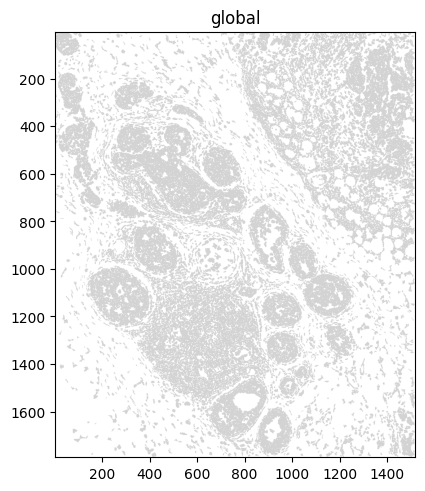

In [4]:
sdata.pl.render_shapes("cell_boundaries").pl.show()

## Initialize SegTraQ objects

Next, we initialize a `SegTraQ` object. The reason for this is that different technologies call things differently: cell centroids could be called `centroid_x`, `x_centroid`, `cell_x`, ...
By initializing a `SegTraQ` object, we only have to tell `SegTraQ` where our data lives once.

Don't worry if you do not know which parameters you need up front; just put in your spatialdata object (`segtraq.SegTraQ(sdata)`), and `SegTraQ` will tell you which arguments are wrong/missing.

In [5]:
st = segtraq.SegTraQ(
    sdata,
    images_key="image",  # where the image is stored
    tables_centroid_x_key="x_centroid",  # where the x centroid is stored
    tables_centroid_y_key="y_centroid",  # where the y centroid is stored
)

Now the data is ready to compute some quality control metrics. `SegTraQ` is structured into different modules, all of which focus on different problems that can arise during segmentation. We will now go through all of the modules and look at what they tell us about our segmentation.

## Baseline module

The baseline (`bl`) module computes basic quality-control metrics such as the number of cells, the percentage of unassigned transcripts, and the number of transcripts and genes per cell. All of the results that `SegTraQ` computes are automatically stored in your `spatialdata` object.

In [6]:
# the number of cells
st.bl.num_cells()

18311

In [7]:
# the percentage of transcripts not assigned to any cell
st.bl.perc_unassigned_transcripts()

10.324546815309601

In [8]:
# the number of transcripts per cell
st.bl.transcripts_per_cell().head()

,cell_id,transcript_count
0,afbommff-1,1352
1,afbjnaja-1,1227
2,afbihifc-1,1216
3,afjdkagk-1,1105
4,aphbncjb-1,1072


In [9]:
# the number of genes per cell
st.bl.genes_per_cell().head()

,cell_id,gene_count
0,acceakgj-1,86
1,accebped-1,95
2,accedpdh-1,50
3,acceejoe-1,57
4,acceekkh-1,48


In [10]:
# the mean number of transcripts per gene per cell
st.bl.mean_transcripts_per_gene_per_cell().head()

,cell_id,mean_transcripts_per_gene
0,acceakgj-1,1.093023
1,accebped-1,1.147368
2,accedpdh-1,1.120000
3,acceejoe-1,1.140351
4,acceekkh-1,1.166667


We can also compute some morphological features of the cells using `bl.morphological_features()`.

In [11]:
st.bl.morphological_features().head()

,cell_id,num_polygons,cell_area,perimeter,circularity,solidity,convexity,elongation,eccentricity,compactness
0,acceakgj-1,1,45.630318,25.596593,0.875183,0.974460,0.983536,1.097515,0.412076,14.358558
1,accebped-1,1,44.433013,25.224078,0.877577,0.969899,0.983684,1.377976,0.688009,14.319400
2,accedpdh-1,1,46.737367,26.267438,0.851214,0.964090,0.984115,1.367124,0.681882,14.762883
3,acceejoe-1,1,33.030204,22.242175,0.839009,0.968244,0.978508,1.214174,0.567164,14.977635
4,acceekkh-1,1,40.730569,23.923744,0.894277,0.982569,0.987680,1.117125,0.445754,14.051989


## Clustering stability module
The clustering stability (`cs`) module provides metrics for assessing the stability of clustering results across different clustering resolutions and random subsets of genes.
The idea is as follows: the better a segmentation method separates cell types, the better it is. We can compute a couple of metrics to investigate this.

Let`s first perform Leiden clustering and visualize the clusters in the UMAP space.

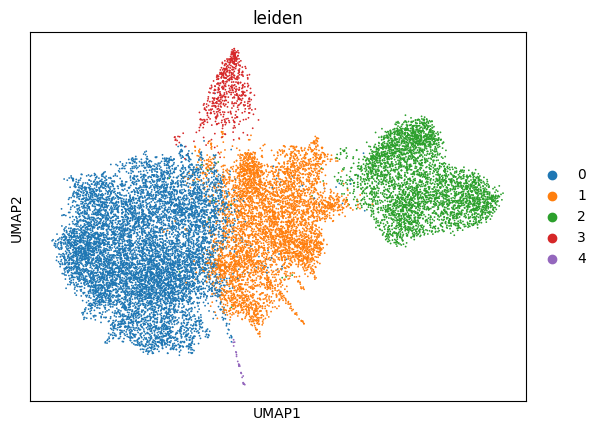

In [12]:
# extracting the anndata object from the spatialdata object and performing appropriate normalization
adata = st.sdata.tables["table"].copy()
sc.pp.normalize_total(adata, inplace=True)
sc.pp.log1p(adata)
sc.pp.pca(adata)
sc.pp.neighbors(adata)
sc.tl.umap(adata)
sc.tl.leiden(adata, flavor="igraph", n_iterations=2, resolution=0.2)

# plotting the result of the leiden clustering
sc.pl.umap(adata, color="leiden")

We can start by looking at the cluster connectedness. To compute it, we use the neighborhood graph we computed with scanpy earlier. The method then iterates over all cells and computes the number of neighbors with the same cluster assignment and divides it by the number of total neighbors. In general, the higher this value is, the better. By default, this is done at a resolution of 0.2, but you can adjust this with the `resolution` parameter.

In [13]:
st.cs.cluster_connectedness()

0.8181104258159327

We can do the same with the silhouette score.

In [14]:
st.cs.silhouette_score()

-0.036610573530197144

Next, we can check how stable the clustering is when we only take a subset (63%) of our genes and run clustering on this. We do this five times, and then assess the quality with the adjusted Rand index (ARI) and the purity. For more details on these metrics, refer to the section on this module.

In [15]:
st.cs.adjusted_rand_index()

0.5906698766026561

In [16]:
st.cs.purity()

0.7491603025132378

## Region similarity module

While individual genes may exhibit subcellular localization patterns, the overall distribution of transcripts, when averaged across genes, is expected to be relatively smooth and approximately uniform within a cell. Based on this assumption, the region similarity module evaluates the similarity of gene expression profiles across different subcellular compartments. Deviations from this expected intra-cellular consistency can serve as indicators of transcript contamination originating from neighboring cells.

### Similarity between nucleus and cytoplasm
First, we look at the correlation between a cell's nucleus and the rest of the cell. A high similarity here means that there is littly contamination, whereas a low correlation can hint towards spillover from adjacent cells.

In [17]:
st.rs.similarity_nucleus_cytoplasm().head()

,cell_id,nucleus_id,iou,nucleus_fraction,similarity_nucleus_cytoplasm
0,acceakgj-1,0.0,0.617026,1.000000,0.031200
1,accebped-1,1.0,0.556906,0.999997,0.021509
2,accedpdh-1,2.0,0.427579,0.997749,0.051412
3,acceejoe-1,3.0,0.708851,1.000000,NaN
4,acceekkh-1,4.0,0.543778,1.000000,0.000000


### Similarity between a cell's center and border

We can also compute the similarity between a cells center and outer shell (transcripts close to the cell membrane).

In [18]:
st.rs.similarity_center_border().head()

,cell_id,similarity_center_border
0,acceakgj-1,0.093956
1,accebped-1,0.030654
2,accedpdh-1,0.000000
3,acceejoe-1,0.000000
4,acceekkh-1,0.000000


### Similarity between a cell's border the cellular neighborhood

Next to that, we can also compute the similarity between a cells outer shell (transcripts close to the cell membrane) and its surrounding cells. 

In [19]:
st.rs.similarity_border_neighborhood().head()

,cell_id,similarity_border_neighborhood
0,acceakgj-1,0.086614
1,accebped-1,0.106757
2,accedpdh-1,0.048416
3,acceejoe-1,0.133129
4,acceekkh-1,0.115372


### Border admixture score

A low `similarity_center_border` or high `similarity_border_neighborhood` does not necessarily represent contamination. To evaluate the contamination of the cell border robustly, we compute the the `border_admixture_score`, which explicitly models the border as a mixture of center and neighborhood expression, and estimates how much better this mixture explains the border compared to the center alone.


In [20]:
st.rs.border_admixture_score().head()

,cell_id,border_admixture_score,border_admixture_score_ci_low,border_admixture_score_ci_high
0,acceakgj-1,0.239112,0.181372,0.403853
1,accebped-1,0.264332,0.194541,0.479611
2,accedpdh-1,0.441111,0.260277,0.563482
3,acceejoe-1,0.549694,0.431815,0.681138
4,acceekkh-1,0.333450,0.202648,0.429744


## Supervised module

The `sp` (supervised) module provides metrics to evaluate how well cell profiles in a spatial transcriptomics dataset agree with a reference single-cell RNA-seq (scRNA-seq) dataset with cell type annotations.

Unlike scRNA-seq, contamination in spatial transcriptomics measurements mostly originates from the local tissue context. 

By comparing spatial expression profiles to a high-quality scRNA-seq reference, the supervised module aims to quantify this mismatch. Specifically, we compute metrics that measure:
- how well each spatial cell matches its expected cell type,
- how much its expression resembles other (neighboring) cell types, and
- if it is possible to predict that a cell of one cell type is adjacent to a different cell type.

To obtain cell-type specific marker genes, we define positive and negative markers in the annotated scRNA-seq via `markers_from_reference`.

In [22]:
adata_ref = ad.read_h5ad("../../data/xenium_5K_data/BC_scRNAseq_Janesick.h5ad")

### Computing cell-type specific markers

In [24]:
# hiding all warnings
with warnings.catch_warnings():
    warnings.simplefilter("ignore")

    markers = st.markers_from_reference(
        adata_ref,
        ref_cell_type="celltype_major",
        ref_raw_counts_layer="raw",
        n_jobs=16,
    )

Below, we show the number of negative markers that overlap with the positive markers of each cell type.  
To reliably estimate contamination, each cell type should share **at least ~5 negative markers** with the positive marker set of every other cell type. If these overlaps are too small, contamination estimates become unstable.

In such cases, the marker definition can be relaxed by adjusting the thresholds used in `markers_from_reference` above.

In [25]:
ctypes = list(markers.keys())
overlap_df = pd.DataFrame(0, index=ctypes, columns=ctypes, dtype=int)

for c in ctypes:
    neg_c = set(markers[c].get("negative", []))
    for d in ctypes:
        pos_d = set(markers[d].get("positive", []))
        overlap_df.loc[c, d] = len(neg_c & pos_d)

overlap_df

,B,DCIS1,DCIS2,T,dendritic,endo,macro,mast,myoepi,perivas,stromal,tumor
B,0,47,38,26,50,106,71,27,92,95,86,25
DCIS1,52,0,17,50,68,89,75,27,28,53,63,19
DCIS2,50,17,0,54,65,91,73,28,54,65,77,6
T,41,85,85,0,72,108,96,37,98,118,103,74
dendritic,27,49,40,30,0,102,49,23,79,76,78,28
endo,45,35,27,38,50,0,60,24,52,4,30,26
macro,29,47,42,26,42,96,0,19,79,86,84,32
mast,45,50,57,42,70,83,70,0,68,99,97,42
myoepi,43,11,5,34,51,62,48,20,0,33,41,17
perivas,51,40,32,31,54,46,80,29,55,0,38,29


### Label transfer

Before we can do statistics on the spatial data, we first need to transfer our cell type labels onto the spatial transcriptomics data. We can do this simply by calling `run_label_transfer()`.

In [26]:
st.run_label_transfer(adata_ref, ref_cell_type="celltype_major", ref_raw_counts_layer="raw")

Let's quickly verify that this worked by plotting the data.

In [27]:
# Replace NaN with Unknown for plotting
s = st.sdata.tables["table"].obs["transferred_cell_type"]
if pd.api.types.is_categorical_dtype(s):
    s = s.cat.add_categories(["Unknown"])

st.sdata.tables["table"].obs["transferred_celltype_plot"] = s.fillna("Unknown")

# before we can plot, we need to link the shapes to the table
st.sdata.tables["table"].obs["region"] = "cell_boundaries"
st.sdata.set_table_annotates_spatialelement("table", region="cell_boundaries")

INFO     Using 'datashader' backend with 'None' as reduction method to speed up plotting. Depending on the         
         reduction method, the value range of the plot might change. Set method to 'matplotlib' to disable this    
         behaviour.                                                                                                


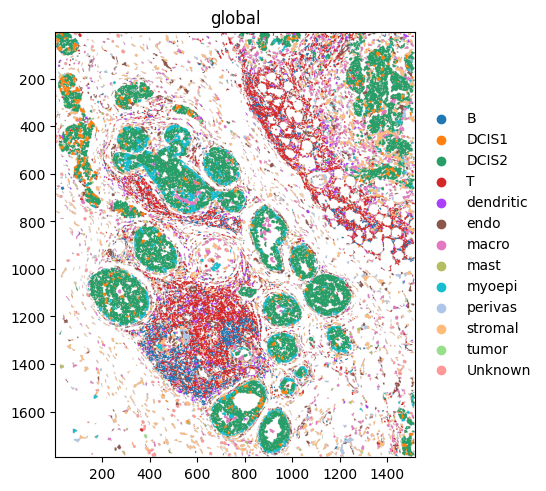

In [28]:
st.sdata.pl.render_shapes("cell_boundaries", color="transferred_celltype_plot").pl.show(coordinate_systems="global")

### Marker purity

To quantify how well each segmented cell in the spatial transcriptomics data matches its annotated cell type, we defined a marker-based purity (`marker_balanced_accuracy`) score that jointly evaluates the expression of positive (`positive_marker_recall`) and the absence of neighborhood-associated negative markers (`negative_marker_avoidance`). The method accounts for the spatial context of each cell and is motivated by the assumption that differences between scRNA-seq and spatial transcriptomics-derived cell type profiles arise mainly from local contamination by neighboring cells.

In [29]:
st.sp.marker_purity(cell_type_key="transferred_cell_type", markers=markers).head()

INFO     Creating graph using `generic` coordinates and `None` transform and `1` libraries.                        


,cell_id,positive_marker_recall,negative_marker_avoidance,marker_balanced_accuracy,n_evaluated_positive_markers,n_evaluated_negative_markers
0,acceakgj-1,0.054545,1.0,0.527273,110,3
1,accebped-1,0.072727,1.0,0.536364,110,5
2,accedpdh-1,0.016667,1.0,0.508333,120,5
3,acceejoe-1,0.054545,1.0,0.527273,110,4
4,acceekkh-1,0.063636,1.0,0.531818,110,18


These metrics are most informative when considered jointly. For an example, please refer to the [Xenium Focus](10x_xenium_focus.ipynb).

### Neighborhood contamination

Marker purity summarizes how well a cell matches its own markers and avoids neighborhood-relevant negatives. In many cases, we also want to quantify (i) **how many contaminating transcripts** are present per cell and (ii) **which neighboring cell types** contribute to this signal. We therefore compute neighborhood contamination.

In [30]:
per_cell_df, _, _, _ = st.sp.neighbor_contamination(cell_type_key="transferred_cell_type", markers=markers)
per_cell_df.head()

,cell_id,contamination_counts,contamination_strength
0,acceakgj-1,0.0,0.0
1,accebped-1,0.0,0.0
2,accedpdh-1,0.0,0.0
3,acceejoe-1,0.0,0.0
4,acceekkh-1,0.0,0.0


The heatmap below summarizes contamination strength for each source–target cell-type pair. Each entry represents the mean contamination strength across all evaluable target cells of the given target cell type, where the source-specific contamination strength is computed as the fraction of transcripts in the target cell that correspond to contamination-relevant markers of the source cell type.

The bubble plot illustrates the contamination strength (bubble color) and the number of evaluable target cells (bubble size). The number of evaluable cells depends on (i) how frequently the source and target cell types occur as neighbors and (ii) how distinct their expression profiles are, as more transcriptionally distinct cell types have more mutually exclusive marker genes that can be evaluated.

Stromal cells cause a high level of contamination into neighboring cells. 

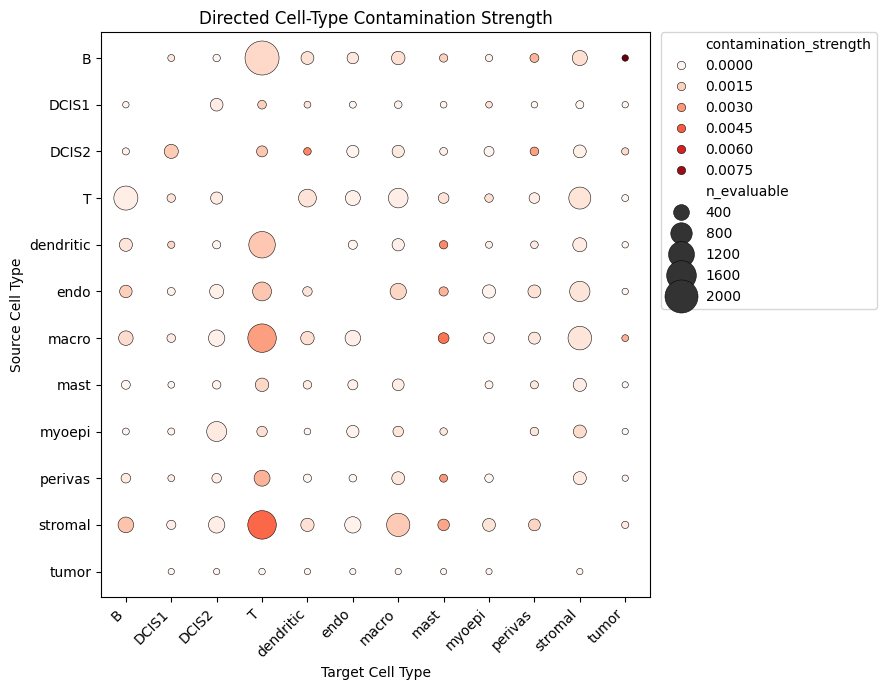

In [31]:
cont_strength_mat = st.sdata.tables[st.tables_key].uns["contamination_strength_matrix"]
cont_n = st.sdata.tables[st.tables_key].uns["contamination_evaluable_cells_matrix"]

plot_df = (
    cont_strength_mat.stack(dropna=False)
    .rename("contamination_strength")
    .reset_index()
    .rename(columns={"level_0": "source", "level_1": "target"})
)

plot_df["n_evaluable"] = cont_n.stack(dropna=False).values

plt.figure(figsize=(9, 7))

ax = sns.scatterplot(
    data=plot_df,
    x="target",
    y="source",
    size="n_evaluable",
    hue="contamination_strength",
    sizes=(20, 600),
    palette="Reds",
    edgecolor="black",
)

ax.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    borderaxespad=0,
)

plt.title("Directed Cell-Type Contamination Strength")
plt.xlabel("Target Cell Type")
plt.ylabel("Source Cell Type")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

#### Mutually exclusive co-expression rate (MECR)

The mutually exclusive co-expression rate (MECR) is a measure for whether combinations of positive and negative markers (computed with a more stringent setting to increase mutual exclusivity, `vote_frac_pos=0.3`) co-occur less often than expected under independence.

In [33]:
tbl = st.sdata["table"]
common_genes = tbl.var_names[tbl.var_names.isin(adata_ref.var_names)]
adata_ref = adata_ref[:, common_genes].copy()

markers = st.markers_from_reference(
    adata_ref,
    ref_cell_type="celltype_major",
    ref_raw_counts_layer="raw",
    mode="de",
    min_pos_frac=0.3,
    n_jobs=16,
)

st.sp.mutually_exclusive_coexpression_rate(markers=markers).head()

,gene1,gene2,odds_ratio,pvalue,a,b,c,d
0,IFI44L,PDGFRA,1.387801,0.904833,17,1031,208,17055
1,EGFR,FCMR,1.161451,0.639582,2,102,374,17833
2,PDGFRB,TMEM45B,1.338869,0.696435,1,374,53,17883
3,ITGB4,SPIB,0.814603,0.415475,2,487,111,17711
4,CTSC,TNFRSF13C,0.745941,0.223918,7,385,455,17464


## 3D Volume Module

The volume (`vl`) accessor provides metrics to assess how well a segmentation method resolves cell overlaps in 3D. Spatial transcriptomics tissue sections have a finite thickness (~4–10 µm), so cells can overlap along the z-dimension and 2D segmentation methods may introduce mixing by assigning transcripts from overlapping cells to the same mask. In this module, we introduce metrics to quantify sensitivity to 3D overlap and evaluate how well quasi-3D methods (e.g. Proseg) disentangle transcripts from overlapping cells. 

For a detailed description of this module, please refer to this [tutorial](volume.ipynb).

### Top-bottom z consistency

To detect potential z-overlap mixing within segmented cells, we split each cell’s transcripts into bottom/top z-quantiles (q=0.30), compute log-normalized gene profiles for both parts, and report their cosine similarity (NaN if either part has <10 transcripts or <5 genes).

In [34]:
st.vl.similarity_top_bottom().head()

,cell_id,similarity_top_bottom
0,acceakgj-1,0.036775
1,accebped-1,0.000000
2,accedpdh-1,0.134356
3,acceejoe-1,0.000000
4,acceekkh-1,0.000000


In [volume.ipynb](./volume.ipynb), we explore the distribution of transcripts along the z-dimension in more depth and put it into context with [ovrlpy](https://www.biorxiv.org/content/10.1101/2025.01.13.632601v2.full), a package for detecting 3D overlap in spatial transcriptomics. There, we use a Xenium v1 dataset with a 313-gene panel, where transcript coverage is higher and the analysis is less affected by sparsity. 

## Point statistic metrics

The point statistics (`ps`) module is designed to compare the distribution of a set of transcripts in the cell relative to its cell centroid or cell border. The idea is to compute the distances of the transcripts to a reference point in the cell, either the cell centroid or the cell boundaries and aggregate this measure per transcript id. 

### Distance of transcripts to the cell membrane

In this metric we compute the distance to the segmented cell membrane of each transcript coordinate and aggregate this metric per transcript id as mean. For examplease, we can compute both the average distance to the cell membrane across all previously defined negative and positive markers for the cell type "DCIS2". 

In [35]:
border_distance_negative = st.ps.distance_to_membrane(
    markers["DCIS2"]["negative"],
    cell_type_key="transferred_celltype_plot",
    cell_type_query=["DCIS2"],
    inplace=False,
)

border_distance_positive = st.ps.distance_to_membrane(
    markers["DCIS2"]["positive"],
    cell_type_key="transferred_celltype_plot",
    cell_type_query=["DCIS2"],
    inplace=False,
)

In [36]:
border_distance_negative.head()

,cell_id,distance_to_cell_membrane_196_genes,cell_area,distance_to_cell_membrane_norm_196_genes
0,aelegcjd-1,1.421389,258.884963,0.088340
1,aeldpbbo-1,2.507427,176.880632,0.188533
2,hjbdpmpc-1,1.811994,262.673512,0.111802
3,hjbcgooh-1,1.801255,102.683823,0.177756
4,aeldbffd-1,1.841093,135.493824,0.158167


In [37]:
border_distance_positive.head()

,cell_id,distance_to_cell_membrane_71_genes,cell_area,distance_to_cell_membrane_norm_71_genes
0,hjbbcfmf-1,1.996653,173.102552,0.151758
1,hjappign-1,1.115476,66.878803,0.136400
2,aelekoij-1,1.851164,227.247765,0.122799
3,aelggapo-1,2.317616,253.712191,0.145503
4,aeldconk-1,1.145413,81.666930,0.126747


## Session Info

In [38]:
print(sd.__version__)  # spatialdata
print(spatialdata_plot.__version__)

0.8.0
0.2.13
